# PySpark, the Big Data approach: 1 year (2024)

This notebook runs the same analysis as the pandas version, but through Apache Spark, which is the Big Data engine that splits the work into chunks and processes them in parallel. Instead of loading everything into memory at once like pandas, Spark reads the data in partitions, meaning smaller pieces, and writes to disk when memory runs low, so that it can handle much larger data. The results are the same as pandas, and the number that we care about here is the runtime, which we compare against the single machine baseline.

Requirements: install pyspark, pandas and matplotlib, and have Java 11 or 17 installed. A flight is counted as delayed when its arrival delay is 15 minutes or more.

## 1. Configuration
Here we set which monthly files this run will use.

In [1]:
import os
RAW_DIR = os.path.join("..","Data","Raw")
SPARK_IN = os.path.join("..","Data","SparkInput")
DURATION_LABEL = "1 year (2024)"
TAG = "1year"
FILES = [
"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_1.zip",
"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_2.zip",
"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_3.zip",
"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_4.zip",
"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_5.zip",
"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_6.zip",
"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_7.zip",
"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_8.zip",
"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_9.zip",
"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_10.zip",
"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_11.zip",
"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_12.zip"
]
print("Duration:", DURATION_LABEL, "| files:", len(FILES))

Duration: 1 year (2024) | files: 12


## 2. Prepare the Spark inputs
Spark cannot read the .zip files directly, so we convert each monthly file into a gzipped CSV once and store it under Data/SparkInput, which Spark can read in that compressed form. The step is skipped for any file that has already been converted.

In [2]:
# 2. Prepare inputs for Spark
# Spark cannot read .zip directly, so we convert each monthly zip into a
# gzipped CSV (.csv.gz) once, into Data/SparkInput/. Spark reads .gz natively.
# This is a one-time step per file (cached); large scopes take a few minutes.
import zipfile, gzip, shutil
os.makedirs(SPARK_IN, exist_ok=True)
gz_paths = []
for zname in FILES:
    zpath = os.path.join(RAW_DIR, zname)
    gzpath = os.path.join(SPARK_IN, zname.replace(".zip", ".csv.gz"))
    if not os.path.exists(zpath):
        print("MISSING raw zip:", zname, "-> run the downloader"); continue
    if not os.path.exists(gzpath):
        with zipfile.ZipFile(zpath) as zf:
            csvn = [n for n in zf.namelist() if n.lower().endswith(".csv")][0]
            with zf.open(csvn) as src, gzip.open(gzpath, "wb") as dst:
                shutil.copyfileobj(src, dst, length=8*1024*1024)
    gz_paths.append(gzpath)
print("Spark input files ready:", len(gz_paths))

Spark input files ready: 12


## 3. Start Spark
We start Spark in local mode, meaning the cores of this one computer act as the cluster, with the driver memory capped so that the memory saving compared to pandas can be seen.

In [3]:
# 3. Start Spark (local mode = your laptop's cores act as the cluster)
from pyspark.sql import SparkSession, functions as F
spark = (SparkSession.builder
         .appName(f"flight-delays-{TAG}")
         .master("local[*]")
         .config("spark.driver.memory", "4g")            # memory CAP (pandas needed 38 GB for 10yr!)
         .config("spark.sql.shuffle.partitions", "32")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 4.2.0


## 4. Load and clean
This is the map step, meaning each flight record is read once, cancelled flights are removed, each flight is marked as delayed or not and the departure hour and route are worked out.

In [4]:
# 4. Load + clean (the map step: parse each flight, tag delayed, derive hour/route)
import time
t0 = time.perf_counter()
raw = (spark.read.option("header", True).option("quote", '"').option("escape", '"')
       .csv(gz_paths))
df = raw.select(
    F.col("Year").cast("int").alias("Year"),
    F.col("Reporting_Airline").alias("carrier"),
    F.col("Origin"), F.col("Dest"),
    F.col("CRSDepTime").cast("int").alias("crs"),
    F.col("ArrDelay").cast("double").alias("arr"),
    F.col("Cancelled").cast("double").alias("canc"),
    F.col("CarrierDelay").cast("double"), F.col("WeatherDelay").cast("double"),
    F.col("NASDelay").cast("double"), F.col("SecurityDelay").cast("double"),
    F.col("LateAircraftDelay").cast("double"))
df = df.filter((F.col("canc") != 1) | F.col("canc").isNull())          # drop cancelled
df = df.withColumn("delayed", F.when(F.col("arr") >= 15, 1).otherwise(0))
df = df.withColumn("dep_hour", F.least(F.greatest((F.col("crs")/100).cast("int"), F.lit(0)), F.lit(23)))
df = df.withColumn("route", F.concat_ws("-", "Origin", "Dest"))
df = df.cache()
n_rows = df.count()
load_secs = time.perf_counter() - t0
print(f"Loaded {n_rows:,} rows in {load_secs:,.1f}s")

Loaded 6,982,746 rows in 8.5s


## 5. Analysis
This is the reduce step, meaning the group by aggregations that summarize each group. In Spark these run as map-reduce work spread across the machine, and they produce the same five result tables as the pandas version.

In [5]:
# 5. Analysis (the reduce step: group-by aggregation = map-reduce in Spark)
def agg(gcol):
    return (df.groupBy(gcol).agg(
        F.count(F.lit(1)).alias("flights"),
        F.avg("arr").alias("avg_arr_delay"),
        (F.avg("delayed")*100).alias("pct_delayed")))

by_carrier = agg("carrier").orderBy(F.desc("pct_delayed")).toPandas().set_index("carrier")
by_airport = agg("Origin").filter("flights >= 1000").orderBy(F.desc("pct_delayed")).toPandas().set_index("Origin")
by_route   = agg("route").filter("flights >= 500").orderBy(F.desc("pct_delayed")).toPandas().set_index("route")
by_hour    = agg("dep_hour").orderBy("dep_hour").toPandas().set_index("dep_hour")

causes = ["CarrierDelay","WeatherDelay","NASDelay","SecurityDelay","LateAircraftDelay"]
cause_by_year = df.groupBy("Year").agg(*[F.sum(c).alias(c) for c in causes]).orderBy("Year").toPandas().set_index("Year")
cause_mix = cause_by_year.div(cause_by_year.sum(axis=1), axis=0) * 100
by_carrier.head(15)

,flights,avg_arr_delay,pct_delayed
carrier,,,
F9,203789,15.247771,28.696838
AA,969054,15.307916,26.054792
B6,236547,10.739642,25.416091
NK,256105,8.415318,23.882002
AS,241008,4.467858,22.009228
OH,224220,10.026785,21.717064
G4,115192,9.710381,21.613480
MQ,275970,6.457716,20.810958
WN,1407647,5.125102,20.560126


## 6. Performance
We record the total runtime, which is the number compared against pandas for the same data size. Because Spark partitions the data and writes to disk when needed, its memory stays bounded rather than growing with the data.

In [6]:
# 6. Performance (record for the pandas-vs-Spark comparison)
total_secs = time.perf_counter() - t0
print(f"Engine            : PySpark (local mode)")
print(f"Duration analysed : {DURATION_LABEL}")
print(f"Rows              : {n_rows:,}")
print(f"Load time         : {load_secs:,.1f} s")
print(f"Total runtime     : {total_secs:,.1f} s")
print(f"Driver memory cap : 4 GB  (pandas needed ~38 GB for 10yr)")

Engine            : PySpark (local mode)
Duration analysed : 1 year (2024)
Rows              : 6,982,746
Load time         : 8.5 s
Total runtime     : 12.3 s
Driver memory cap : 4 GB  (pandas needed ~38 GB for 10yr)


## 7. Charts
We build the same five charts as the pandas version, shown in a different color so that the Spark output can be told apart.

charts built


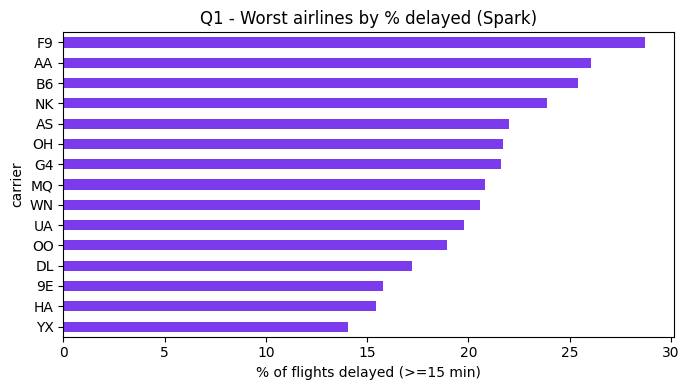

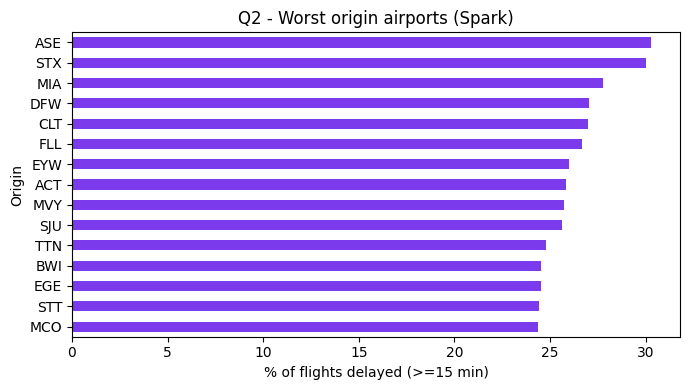

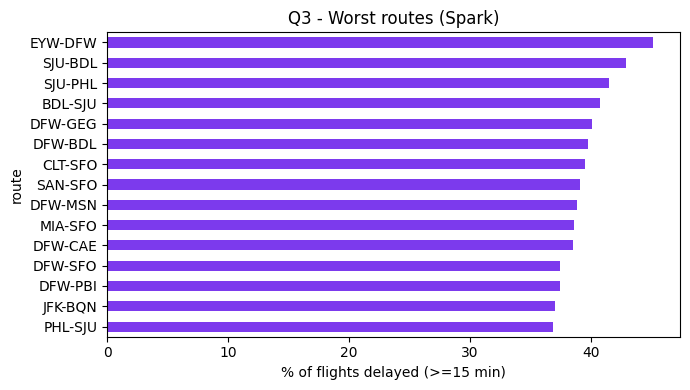

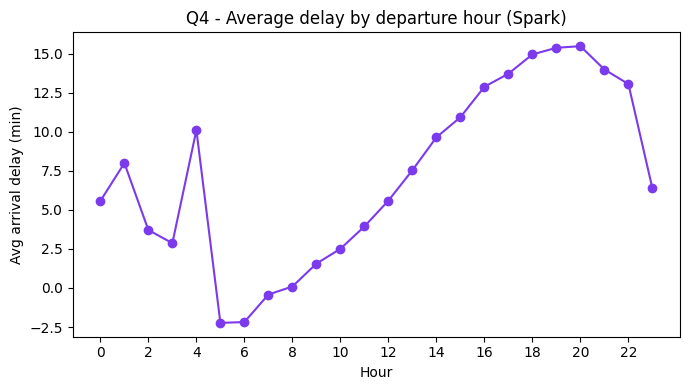

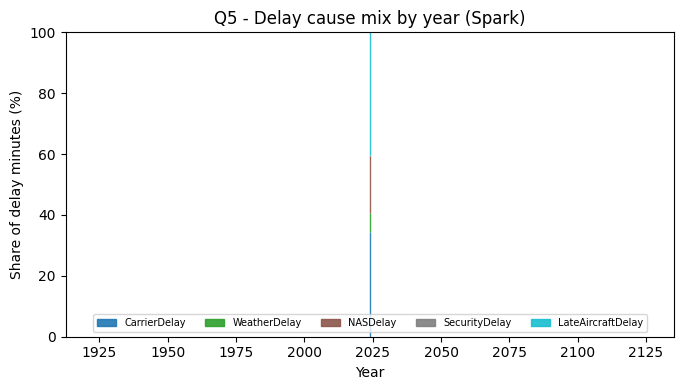

In [7]:
# 7. Charts (same five outputs as pandas)
import matplotlib.pyplot as plt
BLUE="#7c3aed"  # purple to distinguish Spark charts from pandas (blue)
figs={}
def bar(series,title):
    fig,ax=plt.subplots(figsize=(7,4)); series.iloc[::-1].plot.barh(ax=ax,color=BLUE)
    ax.set_title(title); ax.set_xlabel("% of flights delayed (>=15 min)"); fig.tight_layout(); return fig
figs["Q1_carrier"]=bar(by_carrier.head(15)["pct_delayed"],"Q1 - Worst airlines by % delayed (Spark)")
figs["Q2_airport"]=bar(by_airport.head(15)["pct_delayed"],"Q2 - Worst origin airports (Spark)")
figs["Q3_route"]=bar(by_route.head(15)["pct_delayed"],"Q3 - Worst routes (Spark)")
fig,ax=plt.subplots(figsize=(7,4)); by_hour["avg_arr_delay"].plot(ax=ax,marker="o",color=BLUE)
ax.set_title("Q4 - Average delay by departure hour (Spark)"); ax.set_xlabel("Hour"); ax.set_ylabel("Avg arrival delay (min)"); ax.set_xticks(range(0,24,2)); fig.tight_layout(); figs["Q4_hour"]=fig
fig,ax=plt.subplots(figsize=(7,4)); cause_mix.plot.area(ax=ax,cmap="tab10",alpha=0.9)
ax.set_title("Q5 - Delay cause mix by year (Spark)"); ax.set_xlabel("Year"); ax.set_ylabel("Share of delay minutes (%)"); ax.set_ylim(0,100); ax.legend(loc="lower center",ncol=5,fontsize=7); fig.tight_layout(); figs["Q5_causemix"]=fig
print("charts built")

## 8. Output report
This writes a single HTML page under the Output folder, so the tables and charts can be viewed without running any code.

In [8]:
# 8. Write HTML report to Output/spark_<duration>/
import io, base64
OUTPUT_DIR = os.path.join("..","Output","spark_"+TAG); os.makedirs(OUTPUT_DIR, exist_ok=True)
def emb(name,fig):
    fig.savefig(os.path.join(OUTPUT_DIR,name+".png"),dpi=120,bbox_inches="tight")
    buf=io.BytesIO(); fig.savefig(buf,format="png",dpi=120,bbox_inches="tight"); buf.seek(0); plt.close(fig)
    return base64.b64encode(buf.read()).decode()
sections=[("Q1 - Worst airlines (by % delayed)",by_carrier.head(15).round(1),"Q1_carrier"),
          ("Q2 - Worst origin airports",by_airport.head(15).round(1),"Q2_airport"),
          ("Q3 - Worst routes",by_route.head(15).round(1),"Q3_route"),
          ("Q4 - Delay by time of day",by_hour.round(1),"Q4_hour"),
          ("Q5 - Cause mix by year (%)",cause_mix.round(1),"Q5_causemix")]
css="""<style>body{font-family:Segoe UI,Arial,sans-serif;margin:32px;color:#1e293b;max-width:1000px}
h1{color:#5b21b6}h2{color:#7c3aed;border-bottom:2px solid #e2e8f0;padding-bottom:4px;margin-top:32px}
table{border-collapse:collapse;margin:12px 0;font-size:13px}th,td{border:1px solid #cbd5e1;padding:4px 8px;text-align:right}
th{background:#f1f5f9}td:first-child,th:first-child{text-align:left}
.perf{background:#f5f3ff;border:1px solid #ddd6fe;border-radius:8px;padding:12px 16px;margin:12px 0}img{max-width:680px;display:block;margin:8px 0}</style>"""
h=[f"<html><head><meta charset='utf-8'>{css}</head><body>"]
h.append(f"<h1>Flight Delay Analysis - PySpark (big data) - {DURATION_LABEL}</h1>")
h.append("<div class='perf'><b>Run summary (PySpark, local mode)</b><br>"
         f"Rows analysed: {n_rows:,}<br>Load time: {load_secs:,.1f} s<br>"
         f"Total runtime: {total_secs:,.1f} s<br>Driver memory cap: 4 GB (pandas needed ~38 GB for 10yr)</div>")
for title,table,fn in sections:
    h.append(f"<h2>{title}</h2>"); h.append(f"<img src='data:image/png;base64,{emb(fn,figs[fn])}'>"); h.append(table.to_html())
h.append("</body></html>")
with open(os.path.join(OUTPUT_DIR,f"report_spark_{TAG}.html"),"w",encoding="utf-8") as f: f.write("\n".join(h))
# also save CSVs
by_carrier.to_csv(os.path.join(OUTPUT_DIR,f"spark_by_carrier_{TAG}.csv"))
by_airport.to_csv(os.path.join(OUTPUT_DIR,f"spark_by_airport_{TAG}.csv"))
by_route.to_csv(os.path.join(OUTPUT_DIR,f"spark_by_route_{TAG}.csv"))
by_hour.to_csv(os.path.join(OUTPUT_DIR,f"spark_by_hour_{TAG}.csv"))
cause_mix.to_csv(os.path.join(OUTPUT_DIR,f"spark_cause_mix_{TAG}.csv"))
print("Report written to:", os.path.join(OUTPUT_DIR,f"report_spark_{TAG}.html"))

Report written to: ..\Output\spark_1year\report_spark_1year.html


## 9. Stop Spark
We stop Spark at the end to free the resources it was using.

In [9]:
# 9. Stop Spark (frees resources)
spark.stop()
print("Spark stopped.")

Spark stopped.
